# New Section

In [161]:
import pandas as pd

# Load CSV
df = pd.read_csv('/content/drive/MyDrive/AI/Model 2 dataset.csv')

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Basic info
print("Columns:", df.columns)
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nFirst 5 rows:")
# Show first few rows
df.head()

Columns: Index(['date', 'category', 'amount'], dtype='object')
Data types:
 date        datetime64[ns, UTC]
category                 object
amount                  float64
dtype: object

Missing values:
 date        0
category    0
amount      0
dtype: int64

First 5 rows:


,date,category,amount
0,2022-07-06 05:57:10+00:00,Restuarant,5.50
1,2022-07-06 05:57:27+00:00,Market,2.00
2,2022-07-06 05:58:12+00:00,Coffe,30.10
3,2022-07-06 05:58:25+00:00,Market,17.33
4,2022-07-06 05:59:00+00:00,Restuarant,5.50


Initial Data Info with Log Transformation:
                       date    category  amount  amount_log
0 2022-07-06 05:57:10+00:00  Restuarant    5.50    1.871802
1 2022-07-06 05:57:27+00:00      Market    2.00    1.098612
2 2022-07-06 05:58:12+00:00       Coffe   30.10    3.437208
3 2022-07-06 05:58:25+00:00      Market   17.33    2.908539
4 2022-07-06 05:59:00+00:00  Restuarant    5.50    1.871802

Distribution of original amount vs log-transformed amount:


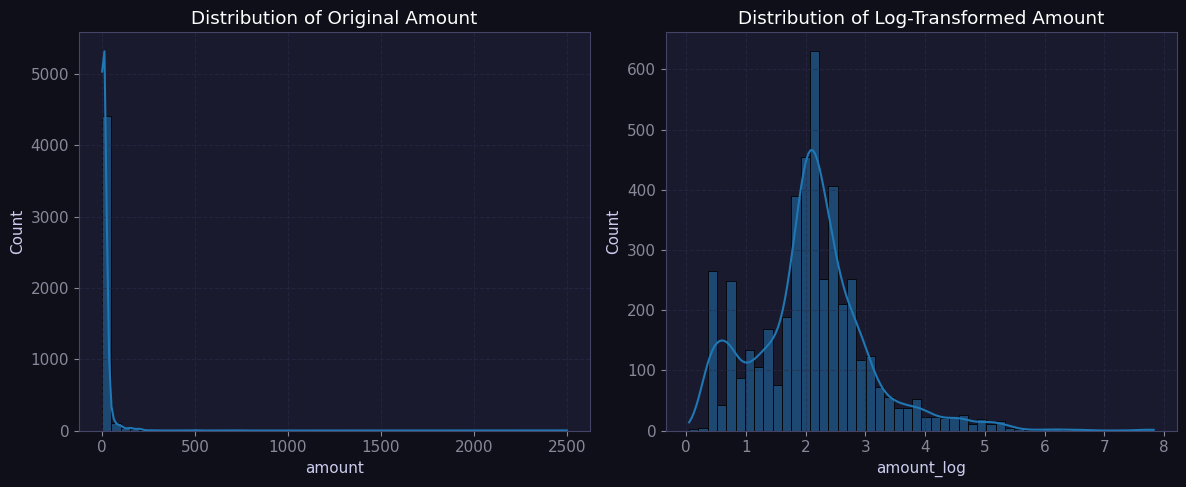

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# --- 1. Data Loading and Initial Preparation ---
file_path = '/content/drive/MyDrive/AI/Model 2 dataset.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# Sort by date for time-series operations
df = df.sort_values('date').reset_index(drop=True)

# Apply log transformation to 'amount' to handle skewness and outliers
df['amount_log'] = np.log1p(df['amount'])

print("Initial Data Info with Log Transformation:")
print(df.head())
print("\nDistribution of original amount vs log-transformed amount:")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Original Amount')
plt.subplot(1, 2, 2)
sns.histplot(df['amount_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Amount')
plt.tight_layout()
plt.show()


In [167]:
# --- 2. Feature Engineering: Lagged and Rolling Features ---

# Create lagged features for the log-transformed amount
LAG_STEPS = [1, 2, 3, 4, 5]
for i in LAG_STEPS:
    df[f'lag_t{i}'] = df['amount_log'].shift(i)

# Create rolling mean and standard deviation features for the log-transformed amount
# Using a window size of 5 to align with the 5 lagged features
df['rolling_mean_5'] = df['amount_log'].rolling(window=5, closed='left').mean()
df['rolling_std_5'] = df['amount_log'].rolling(window=5, closed='left').std()

# Create time-based features (optional, but can be powerful)
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

# One-hot encode 'category'
df = pd.get_dummies(df, columns=['category'], prefix='category', drop_first=True)

# Drop rows with NaN values created by lagging and rolling features
df_processed = df.dropna().reset_index(drop=True)

# Define the features (X) and target (y)
# All category columns
category_cols = [col for col in df_processed.columns if 'category_' in col]

# All numeric features (lags, rolling stats, time features)
LAG_COLS = [f'lag_t{i}' for i in LAG_STEPS]
EXTRA_FEATURES = ['rolling_mean_5', 'rolling_std_5', 'day_of_week', 'month', 'is_weekend']

FEATURES = LAG_COLS + EXTRA_FEATURES + category_cols
TARGET = 'amount_log'

X = df_processed[FEATURES]
y = df_processed[TARGET]

print("Processed Data with Features:")
print(df_processed.head())
print(f"\nNumber of samples after dropping NaNs: {len(df_processed)}")
print(f"Features used: {FEATURES}")

Processed Data with Features:
                       date  amount  amount_log    lag_t1    lag_t2    lag_t3  \
0 2022-07-06 05:59:15+00:00   11.78    2.547881  1.871802  2.908539  3.437208   
1 2022-07-06 05:59:41+00:00   10.00    2.397895  2.547881  1.871802  2.908539   
2 2022-07-06 05:59:44+00:00    1.38    0.867100  2.397895  2.547881  1.871802   
3 2022-07-06 05:59:45+00:00   10.00    2.397895  0.867100  2.397895  2.547881   
4 2022-07-06 05:59:56+00:00    2.73    1.316408  2.397895  0.867100  2.397895   

     lag_t4    lag_t5  rolling_mean_5  rolling_std_5  ...  category_Phone  \
0  1.098612  1.871802        2.237593       0.929264  ...           False   
1  3.437208  1.098612        2.372809       0.911755  ...           False   
2  2.908539  3.437208        2.632665       0.584083  ...           False   
3  1.871802  2.908539        2.118644       0.792694  ...           False   
4  2.547881  1.871802        2.016515       0.691980  ...           False   

   category_Rent Car

Training samples: 3673
Testing samples: 919
Starting GridSearchCV...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best XGBoost parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best MAE on training data (GridSearch): 0.56

Optimized Model Performance (on original scale):
Mean Absolute Error: $5.69
Root Mean Squared Error: $13.09
R2 Score: 0.3273


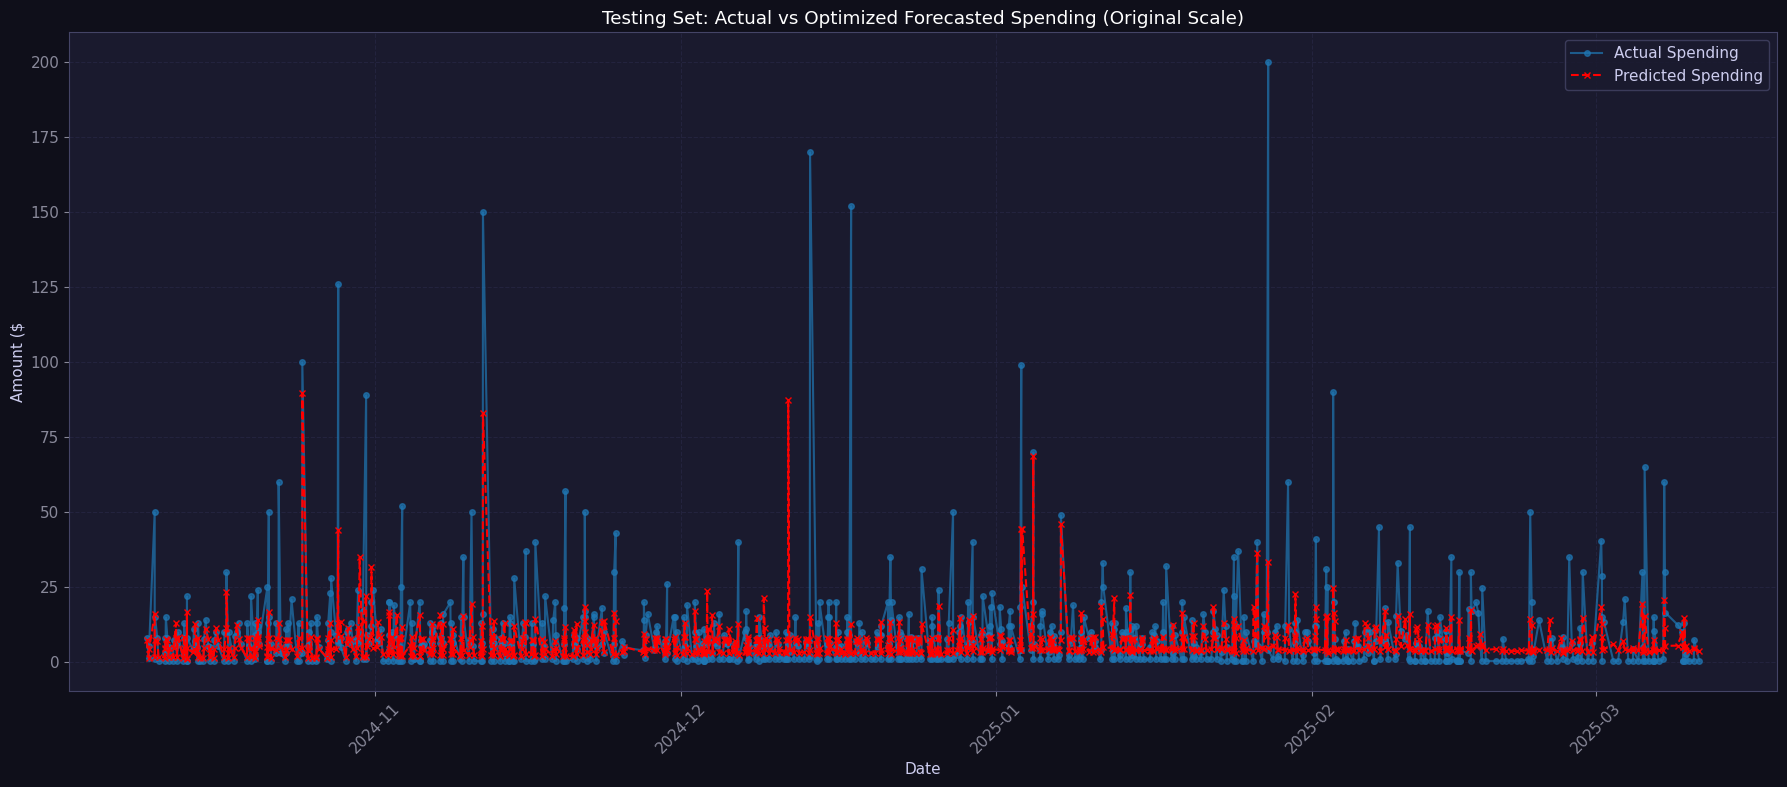

In [176]:
# --- 3. Time Series Train/Test Split ---
# Using an 80/20 split, maintaining chronological order
split_idx = int(len(df_processed) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# --- 4. XGBoost Model Training and Hyperparameter Tuning ---
# Using a GridSearchCV for more robust hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define a parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Initialize XGBRegressor
# Using 'reg:squarederror' for regression objective
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
# For time series, it's critical to use TimeSeriesSplit or avoid shuffling
# Given it's already split chronologically, we can use a simple CV without shuffle
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=3, verbose=1, n_jobs=-1)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

model_optimized = grid_search.best_estimator_
print(f"\nBest XGBoost parameters: {grid_search.best_params_}")
print(f"Best MAE on training data (GridSearch): {-grid_search.best_score_:.2f}")

# --- 5. Model Evaluation (on test set) ---
y_pred_log = model_optimized.predict(X_test)

# Inverse transform predictions and actual values
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"\nOptimized Model Performance (on original scale):")
print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# --- Visualize Predictions vs Actual (Original Scale) ---
plt.figure(figsize=(18, 8)) # Increased figsize for better visibility
plt.plot(df_processed['date'].iloc[split_idx:], y_test_orig, label='Actual Spending', alpha=0.7, marker='o', markersize=4)
plt.plot(df_processed['date'].iloc[split_idx:], y_pred_orig, label='Predicted Spending', linestyle='--', color='red', marker='x', markersize=4)
plt.title("Testing Set: Actual vs Optimized Forecasted Spending (Original Scale)")
plt.xlabel("Date")
plt.ylabel("Amount ($")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exporting the Trained Model

To save your trained `model_optimized` for later use, you can use the `joblib` library (or `pickle`). This allows you to persist the model to disk and load it back without retraining.

In [182]:
import joblib

# Define a file path to save the model
model_filename = 'optimized_xgb_spending_model.joblib'

# Save the trained model
joblib.dump(model_optimized, model_filename)
print(f"Model saved to {model_filename}")

Model saved to optimized_xgb_spending_model.joblib


### Loading the Saved Model

Now, let's simulate loading this model in a new session (or at a later time) to make predictions.

In [183]:
import joblib

# Load the model from the file
loaded_model = joblib.load(model_filename)
print(f"Model loaded from {model_filename}")

# Assign it to model_optimized for consistency with the prediction function
# In a real scenario, you would just use loaded_model directly
model_optimized = loaded_model

Model loaded from optimized_xgb_spending_model.joblib


### Testing with New Input

To test with new input, you need to prepare the data in the exact same format that the `predict_next_spending_optimized` function expects. This means providing:

1.  `last_5_amounts`: A list of 5 *original scale* spending amounts.
2.  `category_name`: The category string for the next prediction.
3.  `current_date`: The date for which the prediction is being made (datetime object or string).

Let's create some new hypothetical input data and use the prediction function.

In [187]:
import pandas as pd
import numpy as np

# --- New Hypothetical Input ---
# Let's say these are the last 5 spending amounts observed
new_last_5_amounts = [15.0, 20.5, 8.2, 30.1, 12.7]

# And you want to predict the spending for a 'Coffee' category
new_category_name = 'Coffe'

# For a future date, for example, two days after the last record in your dataset
# (assuming df_processed is still available from previous execution)
new_current_date = pd.to_datetime(df_processed['date'].iloc[-1]) + pd.Timedelta(days=2)

print(f"New example input last 5 amounts: {new_last_5_amounts}")
print(f"Predicting for category: '{new_category_name}' on date: {new_current_date.strftime('%Y-%m-%d')}")

# Use the prediction function defined earlier
new_predicted_amount, new_predicted_trend = predict_next_spending_optimized(new_last_5_amounts, new_category_name, new_current_date)
print(f"Predicted spending for the new input: ${new_predicted_amount:.2f} ({new_predicted_trend})")

New example input last 5 amounts: [15.0, 20.5, 8.2, 30.1, 12.7]
Predicting for category: 'Coffe' on date: 2025-03-13
Predicted spending for the new input: $9.03 (decrease)


In [188]:
# --- 6. Prediction Interface with New Features ---

def predict_next_spending_optimized(last_5_amounts, category_name, current_date):
    """
    Predicts the next day's spending based on the last 5 actual spending amounts,
    the category of the *last* transaction, and the current date (for time features).
    Inputs:
    - last_5_amounts: A list or array of 5 *original scale* spending amounts.
    - category_name: The category string for the next prediction (e.g., 'Market', 'Restuarant').
    - current_date: The date for which the prediction is being made (datetime object or string parseable to date).
    Output:
    - A tuple containing the predicted next day's spending on the original scale and the trend (increase/decrease/no change).
    """
    if len(last_5_amounts) != 5:
        return "Error: Please provide exactly 5 previous spending amounts.", ""

    # Convert amounts to log scale
    last_5_log = np.log1p(last_5_amounts)

    # Calculate rolling mean and std from last 5 log amounts
    rolling_mean = np.mean(last_5_log)
    rolling_std = np.std(last_5_log)

    # Prepare time features for the next day
    next_day_date = pd.to_datetime(current_date)
    day_of_week = next_day_date.dayofweek
    month = next_day_date.month
    # Ensure is_weekend is a boolean, matching the training data's dtype
    is_weekend = (next_day_date.dayofweek >= 5)

    # Create a dictionary to hold the feature values for the single prediction row
    feature_values = {}

    # Lagged features (ensure float type)
    for i, val in enumerate(last_5_log[::-1]):
        feature_values[f'lag_t{i+1}'] = float(val)

    # Rolling stats (ensure float type)
    feature_values['rolling_mean_5'] = float(rolling_mean)
    feature_values['rolling_std_5'] = float(rolling_std)

    # Time-based features (ensure int type)
    feature_values['day_of_week'] = int(day_of_week)
    feature_values['month'] = int(month)
    feature_values['is_weekend'] = bool(is_weekend) # Ensure boolean type

    # One-hot encoded category features (ensure boolean type)
    for col in category_cols:
        feature_values[col] = False # Initialize all category flags to False
    if f'category_{category_name}' in category_cols:
        feature_values[f'category_{category_name}'] = True # Set the target category flag to True

    # Create an input DataFrame for the model, ensuring correct column order
    input_data = pd.DataFrame([feature_values], columns=FEATURES)

    # Predict on the log scale
    prediction_log = model_optimized.predict(input_data)[0]

    # Inverse transform and ensure non-negative
    prediction_orig = np.expm1(prediction_log)
    predicted_amount = max(0, prediction_orig)

    # Determine trend compared to the very last amount in the input sequence
    last_input_amount = last_5_amounts[-1]
    if predicted_amount > last_input_amount:
        trend = "increase"
    elif predicted_amount < last_input_amount:
        trend = "decrease"
    else:
        trend = "no change"

    return predicted_amount, trend

# --- Example Usage ---
# Let's take the last 5 actual amounts from the processed data for an example
example_last_5_amounts = df_processed['amount'].iloc[-5:].tolist()
example_category = 'Market' # Example category for the predicted day
example_date = df_processed['date'].iloc[-1] + pd.Timedelta(days=1) # Predict for the day after the last record

print(f"Example input last 5 amounts: {example_last_5_amounts}")
print(f"Predicting for category: '{example_category}' on date: {example_date.strftime('%Y-%m-%d')}")

predicted_amount, predicted_trend = predict_next_spending_optimized(example_last_5_amounts, example_category, example_date)
print(f"Predicted spending for the next day: ${predicted_amount:.2f} ({predicted_trend})")

Example input last 5 amounts: [2.88, 0.5, 0.5, 7.5, 0.5]
Predicting for category: 'Market' on date: 2025-03-12
Predicted spending for the next day: $5.02 (increase)
